# Exp-10 Augmented Reality Using Feature Matching

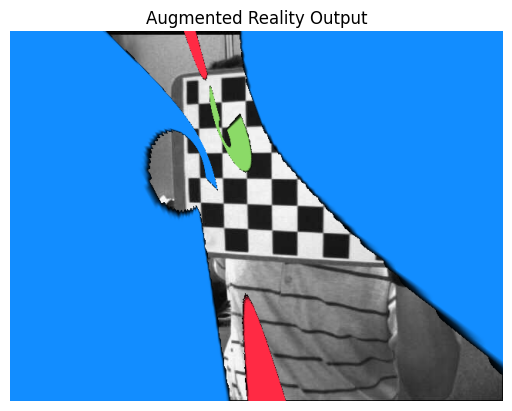

In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread('box.png', 0)          # reference (marker)
img2 = cv2.imread('left01.jpg')          # real-world scene
overlay = cv2.imread('opencv-logo.png')  # image to place

if img1 is None or img2 is None or overlay is None:
    print("Error loading images")
    exit()

# ---------------------------
# Detect features using ORB
# ---------------------------
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# ---------------------------
# Match features
# ---------------------------
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Sort matches (best first)
matches = sorted(matches, key=lambda x: x.distance)

# Take top matches
good_matches = matches[:50]

# ---------------------------
# Get matching points
# ---------------------------
pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)

# ---------------------------
# Find homography (mapping)
# ---------------------------
matrix, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)

# ---------------------------
# Warp overlay image
# ---------------------------
h, w = img1.shape
overlay_resized = cv2.resize(overlay, (w, h))

warped = cv2.warpPerspective(overlay_resized, matrix,
                             (img2.shape[1], img2.shape[0]))

# ---------------------------
# Combine images
# ---------------------------
gray_warped = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
_, mask_overlay = cv2.threshold(gray_warped, 1, 255, cv2.THRESH_BINARY)

mask_inv = cv2.bitwise_not(mask_overlay)

img_bg = cv2.bitwise_and(img2, img2, mask=mask_inv)

result = cv2.add(img_bg, warped)

# ---------------------------
# Show result (Jupyter)
# ---------------------------
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.imshow(result_rgb)
plt.title("Augmented Reality Output")
plt.axis('off')
plt.show()